Image:        4288 x 2848 px
Plate scale:  113.45 arcsec/px
Zenith pixel: (2144, 1424)

Step 1: Enhancing image...
Step 2: Finding edges...
Step 3: Extracting arcs...
  117 arcs found
Step 4: Fitting circles to arcs...
  26 good circle fits
Step 5: Finding pole pixel...
  Pole at (2142.5, 92.7) px  +/-31.1 px
Step 6: Computing latitude...

========== RESULTS ==========
Zenith pixel      : (2144, 1424)
Pole pixel        : (2142.5, 92.7)
Zenith-to-pole    : 1331.3 px  =  41.952 deg
Latitude          : 48.048 deg
Uncertainty       : +/- 0.980 deg  (~+/- 109 km)
Zone              : Temperate
Arcs used         : 26


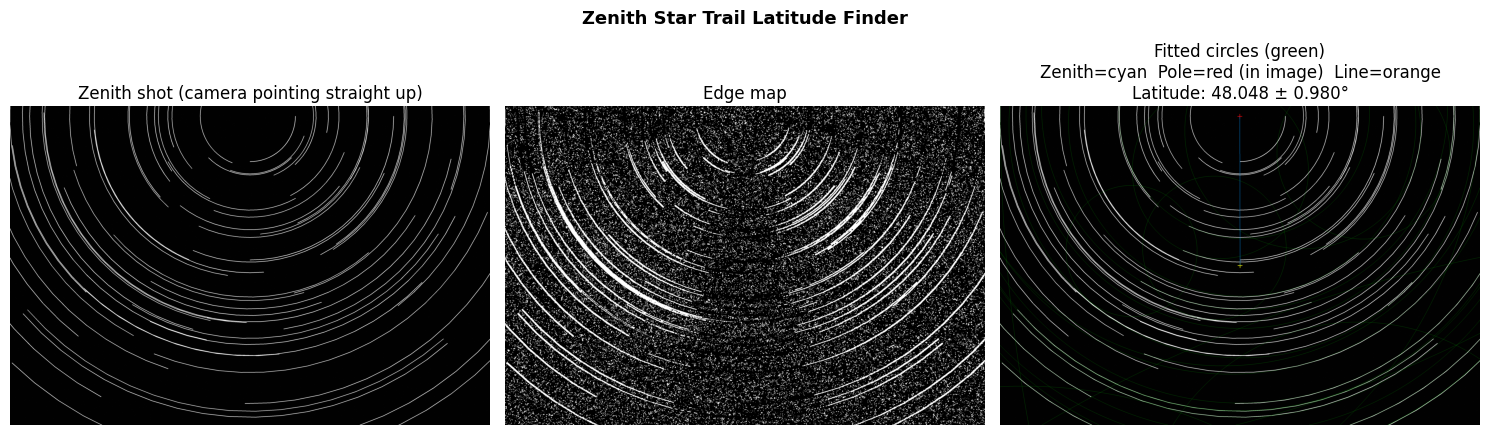

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.optimize import least_squares


# -----------------------------------------------------------------------
# settings
# -----------------------------------------------------------------------

IMAGE_PATH      = "Zenith_star_trails.jpg"

# Nikon D90 + 10mm lens (matches the generator)
FOCAL_LENGTH_MM = 10
PIXEL_SIZE_UM   = 5.50           # Nikon D90
HEMISPHERE      = 'north'        # 'north' or 'south'

# -----------------------------------------------------------------------
# HOW IT WORKS
#
# Camera points straight up  =>  image centre pixel = zenith
#
# Star trails are always circles centred on the celestial pole,
# NOT the zenith. The pole sits at an angular distance of (90 - latitude)
# from the zenith.
#
# So:
#   1. Fit circles to all star trail arcs  (same as pole shot code)
#   2. Find the common centre of those circles  =>  pole pixel
#   3. Measure pixel distance from pole to image centre (= zenith)
#   4. Convert to degrees using plate scale
#   5. latitude = 90 - that angular distance
#
# No horizon needed. No catalogue needed. Pure geometry.
# -----------------------------------------------------------------------


class ZenithLatitudeFinder:

    def __init__(self, image_path, focal_length_mm, pixel_size_um, hemisphere):
        self.img = cv2.imread(image_path)
        if self.img is None:
            raise ValueError(f"Could not open: {image_path}")

        self.gray = cv2.cvtColor(self.img, cv2.COLOR_BGR2GRAY)
        self.height, self.width = self.gray.shape

        # image centre = zenith (assumes camera was level)
        self.zenith_x = self.width  / 2.0
        self.zenith_y = self.height / 2.0

        self.scale_arcsec = 206.265 * pixel_size_um / focal_length_mm
        self.scale_deg    = self.scale_arcsec / 3600.0
        self.hemisphere   = hemisphere.lower()

        # diagonal for reference
        self.diag = math.sqrt(self.width**2 + self.height**2)

        print(f"Image:        {self.width} x {self.height} px")
        print(f"Plate scale:  {self.scale_arcsec:.2f} arcsec/px")
        print(f"Zenith pixel: ({self.zenith_x:.0f}, {self.zenith_y:.0f})")

    # --- image processing ----------------------------------------------

    def _enhance(self):
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        eq = clahe.apply(self.gray)
        dn = cv2.bilateralFilter(eq, 9, 75, 75)
        bl = cv2.GaussianBlur(dn, (0, 0), 3)
        return cv2.addWeighted(dn, 1.5, bl, -0.5, 0)

    def _edges(self, enhanced):
        med = np.median(enhanced)
        canny = cv2.Canny(enhanced,
                          int(max(0,   0.5 * med)),
                          int(min(255, 1.5 * med)))
        sx = cv2.Sobel(enhanced, cv2.CV_64F, 1, 0, ksize=3)
        sy = cv2.Sobel(enhanced, cv2.CV_64F, 0, 1, ksize=3)
        mag = np.sqrt(sx**2 + sy**2)
        mag = np.uint8(255 * mag / (mag.max() + 1e-9))
        _, sobel = cv2.threshold(mag, 40, 255, cv2.THRESH_BINARY)
        combined = cv2.bitwise_or(canny, sobel)
        k = np.ones((3, 3), np.uint8)
        combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, k)
        combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN, k)
        return combined

    def _get_arcs(self, edges, min_length=150):
        """Extract arc contours - increased minimum length for better fits"""
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL,
                                        cv2.CHAIN_APPROX_NONE)
        arcs = []
        for cnt in contours:
            length = cv2.arcLength(cnt, closed=False)
            if length >= min_length:
                arcs.append(cnt.reshape(-1, 2).astype(float))
        return arcs

    # --- circle fitting ------------------------------------------------

    def _fit_circle(self, pts):
        """Fit a circle to points using least squares"""
        x, y = pts[:, 0], pts[:, 1]
        A = np.column_stack([2*x, 2*y, np.ones(len(x))])
        b = x**2 + y**2
        try:
            res, _, rank, _ = np.linalg.lstsq(A, b, rcond=None)
        except np.linalg.LinAlgError:
            return None
        if rank < 3:
            return None
        cx, cy = res[0], res[1]
        r_sq = res[2] + cx**2 + cy**2
        if r_sq < 0:
            return None
        r = math.sqrt(r_sq)

        # Refine with nonlinear least squares
        def residuals(p):
            return np.sqrt((pts[:, 0] - p[0])**2 + (pts[:, 1] - p[1])**2) - p[2]
        try:
            refined = least_squares(residuals, [cx, cy, r], method='lm', max_nfev=500)
            cx, cy, r = refined.x
            r = abs(r)
        except Exception:
            pass

        return cx, cy, r

    def _find_circles(self, arcs):
        """Fit circles to arcs, filtering for large radii appropriate for distant pole"""
        
        min_expected_radius = 0.1 * self.diag
        
        circles = []

        for pts in arcs:
            if len(pts) < 20:
                continue

            step = max(1, len(pts) // 200)
            sample = pts[::step]
            if len(sample) < 10:
                continue

            fit = self._fit_circle(sample)
            if fit is None:
                continue
            cx, cy, r = fit

            if r < min_expected_radius:
                continue
            if r > 20 * self.diag:
                continue

            d = np.sqrt((sample[:, 0] - cx)**2 + (sample[:, 1] - cy)**2)
            residual_std = np.std(d - r)
            
            max_residual = 3 + 0.002 * r
            if residual_std > max_residual:
                continue

            arc_length = len(pts)
            weight = arc_length * math.sqrt(r / self.diag)
            circles.append((cx, cy, r, weight))

        return circles

    # --- pole finding with MAD outlier rejection ----------------------

    def _find_pole(self, circles):
        """Find the celestial pole from circle centers"""
        if len(circles) < 3:
            return None

        cxs    = np.array([c[0] for c in circles])
        cys    = np.array([c[1] for c in circles])
        rs     = np.array([c[2] for c in circles])
        raw_ws = np.array([c[3] for c in circles])

        # Boundary rejection
        max_dist = 5.0 * self.diag
        img_cx   = self.width  / 2.0
        img_cy   = self.height / 2.0
        dist_from_img = np.sqrt((cxs - img_cx)**2 + (cys - img_cy)**2)
        in_range = dist_from_img < max_dist
        cxs, cys, rs, raw_ws = (cxs[in_range], cys[in_range],
                                 rs[in_range],  raw_ws[in_range])

        if len(cxs) < 3:
            return None

        # Weight by arc length and radius
        arc_lengths = raw_ws * rs / math.sqrt(rs.mean() / self.diag)
        subtended   = arc_lengths / (rs + 1e-9)
        ws = subtended ** 2

        # MAD outlier rejection
        med_x = np.median(cxs)
        med_y = np.median(cys)
        dists = np.sqrt((cxs - med_x)**2 + (cys - med_y)**2)
        mad = np.median(dists)
        
        if mad > 0:
            threshold = 3.0 * mad
            keep = dists <= threshold
            if keep.sum() < 3:
                threshold = 6.0 * mad
                keep = dists <= threshold
        else:
            keep = np.ones(len(cxs), dtype=bool)

        cxs, cys, ws = cxs[keep], cys[keep], ws[keep]
        
        if len(cxs) < 1:
            return None
            
        ws = ws / ws.sum()

        pole_x = np.average(cxs, weights=ws)
        pole_y = np.average(cys, weights=ws)

        ux = math.sqrt(np.average((cxs - pole_x)**2, weights=ws)) if len(cxs) > 1 else 100
        uy = math.sqrt(np.average((cys - pole_y)**2, weights=ws)) if len(cys) > 1 else 100
        uncertainty = math.sqrt(ux**2 + uy**2)

        return pole_x, pole_y, uncertainty

    # --- latitude from zenith-to-pole distance ------------------------

    def _compute_latitude(self, pole_x, pole_y, pole_err_px):
        dx = pole_x - self.zenith_x
        dy = pole_y - self.zenith_y
        pole_dist_px  = math.sqrt(dx**2 + dy**2)

        pole_dist_deg = pole_dist_px * self.scale_deg

        latitude = 90.0 - pole_dist_deg
        if self.hemisphere == 'south':
            latitude = -abs(latitude)

        lat_err = pole_err_px * self.scale_deg

        return latitude, lat_err, pole_dist_deg, pole_dist_px

    # --- main ---------------------------------------------------------

    def run(self):
        print("\nStep 1: Enhancing image...")
        enhanced = self._enhance()

        print("Step 2: Finding edges...")
        edges = self._edges(enhanced)

        print("Step 3: Extracting arcs...")
        arcs = self._get_arcs(edges)
        print(f"  {len(arcs)} arcs found")

        if len(arcs) < 3:
            print("Too few arcs. Try a longer exposure or darker sky.")
            return

        print("Step 4: Fitting circles to arcs...")
        circles = self._find_circles(arcs)
        print(f"  {len(circles)} good circle fits")

        if len(circles) < 3:
            print("Too few valid fits. Image may be too noisy or trails too short.")
            return

        print("Step 5: Finding pole pixel...")
        pole = self._find_pole(circles)
        if pole is None:
            print("Could not locate pole.")
            return

        pole_x, pole_y, pole_err = pole
        print(f"  Pole at ({pole_x:.1f}, {pole_y:.1f}) px  +/-{pole_err:.1f} px")

        print("Step 6: Computing latitude...")
        latitude, lat_err, pole_dist_deg, pole_dist_px = \
            self._compute_latitude(pole_x, pole_y, pole_err)

        print("\n========== RESULTS ==========")
        print(f"Zenith pixel      : ({self.zenith_x:.0f}, {self.zenith_y:.0f})")
        print(f"Pole pixel        : ({pole_x:.1f}, {pole_y:.1f})")
        print(f"Zenith-to-pole    : {pole_dist_px:.1f} px  =  {pole_dist_deg:.3f} deg")
        print(f"Latitude          : {latitude:.3f} deg")
        print(f"Uncertainty       : +/- {lat_err:.3f} deg  (~+/- {lat_err*111:.0f} km)")
        z = abs(latitude)
        zone = "Arctic/Antarctic" if z > 66.5 else ("Temperate" if z > 23.5 else "Tropical")
        print(f"Zone              : {zone}")
        print(f"Arcs used         : {len(circles)}")
        print("==============================")

        self._plot(edges, circles, pole_x, pole_y, latitude, lat_err, pole_dist_px)

        return latitude, lat_err

    # --- final plot ---------------------------------------------------

    def _plot(self, edges, circles, pole_x, pole_y, latitude, lat_err, pole_dist_px):
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle("Zenith Star Trail Latitude Finder", fontsize=13, fontweight='bold')

        axes[0].imshow(cv2.cvtColor(self.img, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Zenith shot (camera pointing straight up)")
        axes[0].axis('off')

        axes[1].imshow(edges, cmap='gray')
        axes[1].set_title("Edge map")
        axes[1].axis('off')

        overlay = self.img.copy()

        for cx, cy, r, _ in circles:
            cv2.circle(overlay, (int(cx), int(cy)), int(r), (0, 200, 0), 1)

        cv2.drawMarker(overlay,
                       (int(self.zenith_x), int(self.zenith_y)),
                       (0, 255, 255), cv2.MARKER_CROSS, 40, 3)

        pole_in_image = (0 <= pole_x <= self.width and 0 <= pole_y <= self.height)
        if pole_in_image:
            cv2.drawMarker(overlay,
                           (int(pole_x), int(pole_y)),
                           (0, 0, 255), cv2.MARKER_CROSS, 40, 3)

        cv2.line(overlay,
                 (int(self.zenith_x), int(self.zenith_y)),
                 (int(pole_x), int(pole_y)),
                 (255, 150, 0), 2)

        axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        pole_status = "in image" if pole_in_image else "outside image"
        axes[2].set_title(
            f"Fitted circles (green)\n"
            f"Zenith=cyan  Pole=red ({pole_status})  Line=orange\n"
            f"Latitude: {latitude:.3f} ± {lat_err:.3f}°"
        )
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()


# -----------------------------------------------------------------------

if __name__ == "__main__":
    finder = ZenithLatitudeFinder(
        image_path      = IMAGE_PATH,
        focal_length_mm = FOCAL_LENGTH_MM,
        pixel_size_um   = PIXEL_SIZE_UM,
        hemisphere      = HEMISPHERE,
    )
    finder.run()
